In [168]:
import os
import tarfile
from six.moves import urllib
import pandas as pd
import numpy as np
from zlib import crc32
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from pandas.plotting import scatter_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from scipy import stats

In [77]:
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

In [78]:
# function to load data
def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

In [79]:
fetch_housing_data()
housing = load_housing_data()
housing.head()

C:\Users\ISSA\AppData\Local\Temp\ipykernel_18012\632633212.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [80]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [81]:
#to check below to each category of ocean proximity
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [82]:
# shows the summary of the numerical attributes in dataset
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


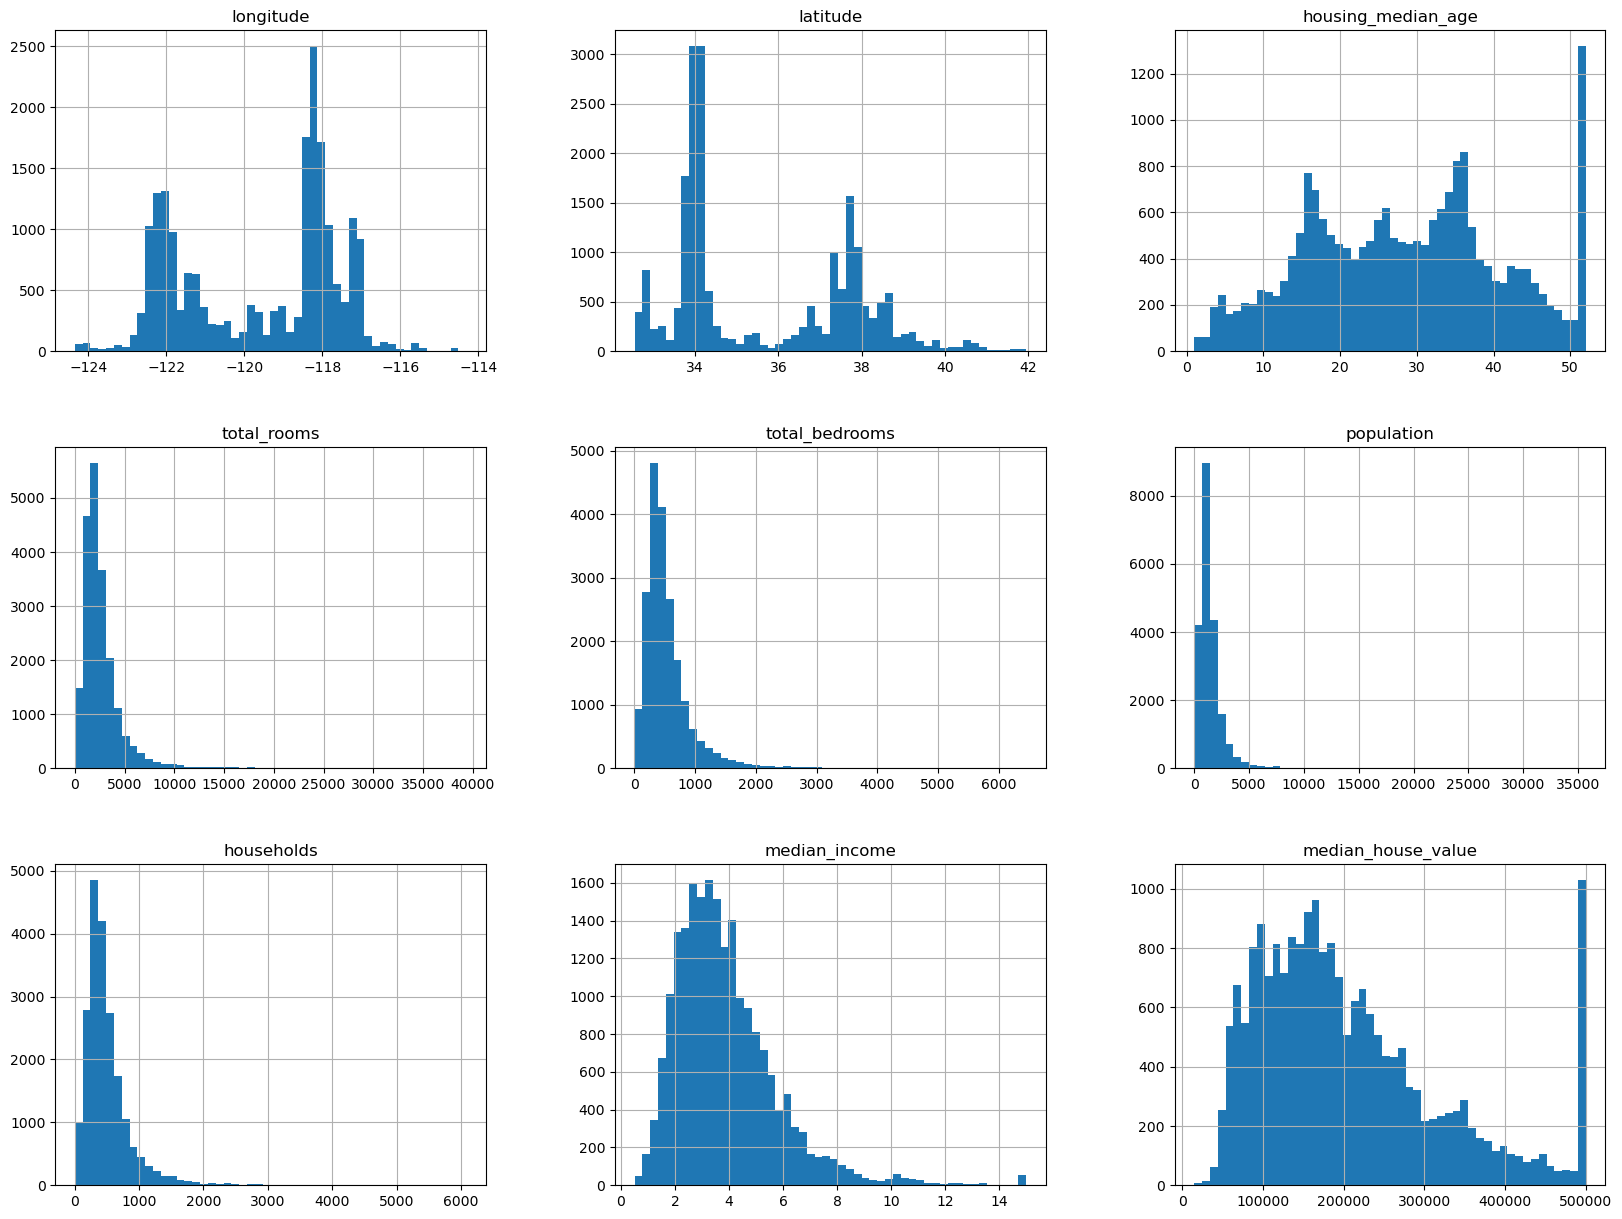

In [83]:
housing.hist(bins=50, figsize=(20,15))
plt.show()

In [84]:
def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [85]:
# split data into train and test dataset
train_set, test_set = split_train_test(housing, 0.2)

In [86]:
len(train_set)

16512

In [87]:
len(test_set)

4128

In [88]:
def test_set_check(identifier, test_ratio):
    return crc32(np.int64(identifier)) & 0xffffffff < test_ratio * 2**32

In [89]:
def split_train_test_by_id(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_,test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [90]:
housing_with_id = housing.reset_index()
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "index")

In [91]:
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "id")

In [92]:
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

In [93]:
housing["income_cat"] = pd.cut(housing["median_income"], bins=[0., 1.5, 3.0,4.5,6., np.inf],
                               labels=[1,2,3,4,5])

<Axes: >

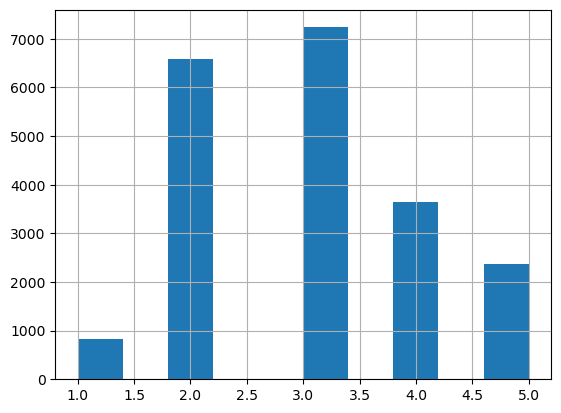

In [94]:
housing["income_cat"].hist()

In [95]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

In [96]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [97]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [98]:
housing = strat_train_set.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

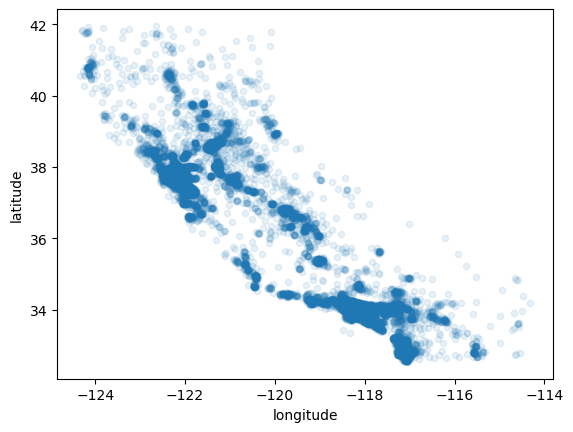

In [99]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

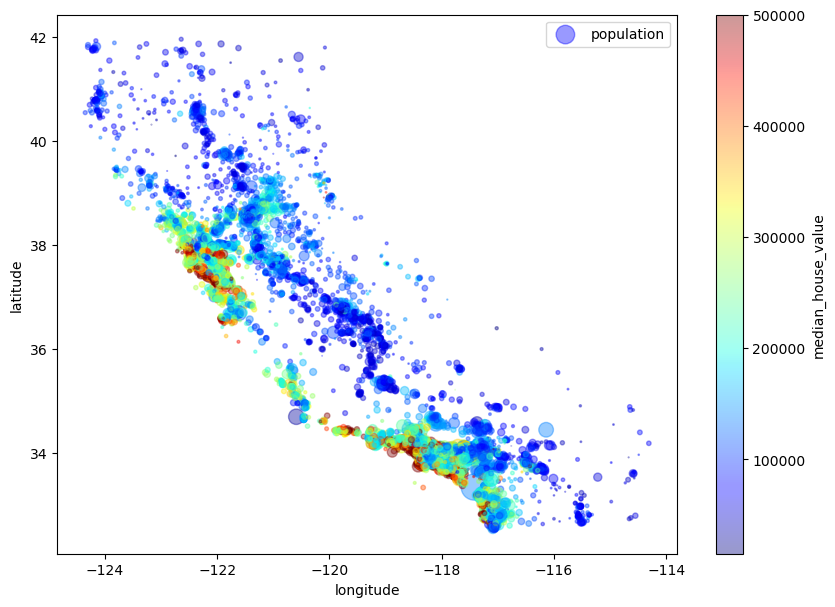

In [100]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4, s=housing["population"]/100,
             label="population", figsize=(10,7), c="median_house_value", cmap=plt.get_cmap("jet"),
             colorbar=True,)
plt.legend()            

In [101]:
corr_matrix = housing.corr(numeric_only=True)


In [102]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

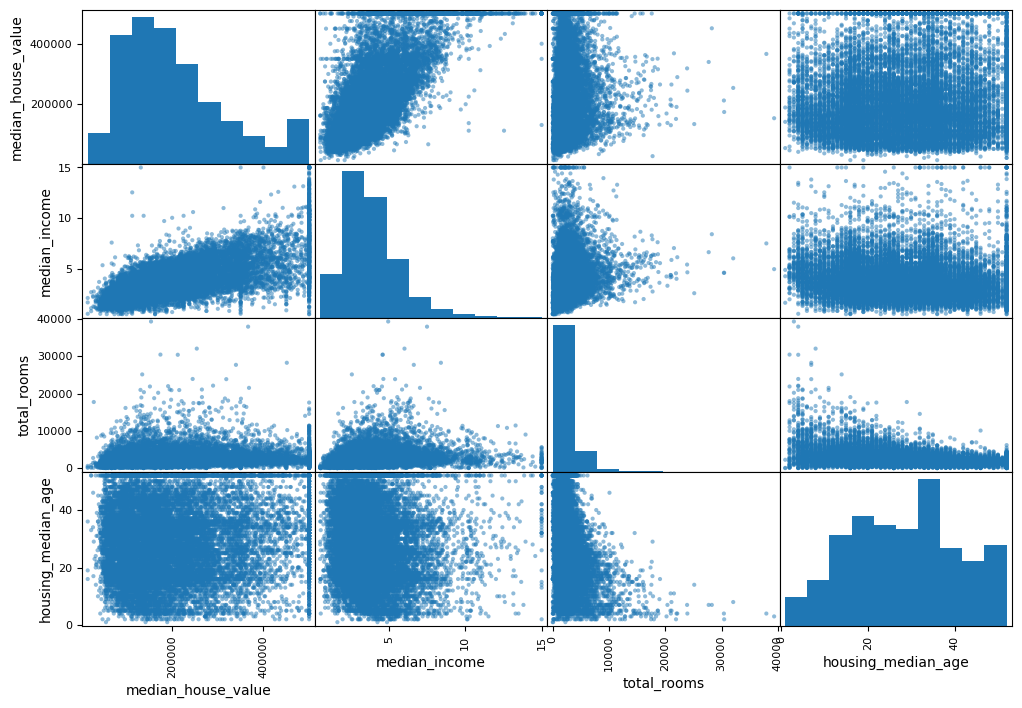

In [103]:
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12,8))

<Axes: xlabel='median_income', ylabel='median_house_value'>

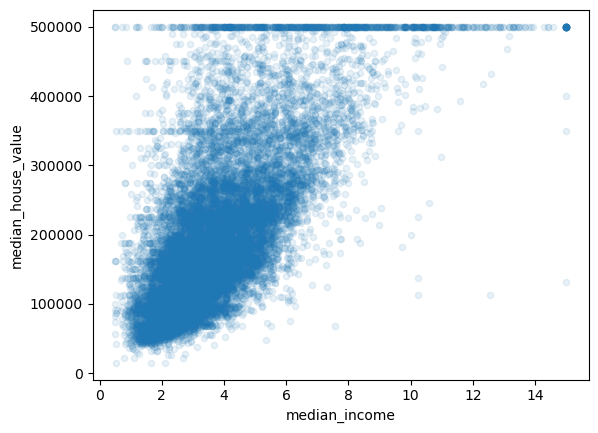

In [104]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1)

In [105]:
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"] = housing["population"]/housing["households"]

In [106]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64

In [107]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [108]:
# handle missing value using median for any numeric attribute, and we need to store that value for any other place usage
imputer = SimpleImputer(strategy="median")

In [109]:
#create the data without text value
housing_num = housing.drop("ocean_proximity", axis=1)

#only the total_bedrooms has missing value but not sure in live system if no other attribute will have not missings
imputer.fit(housing_num)

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [110]:
imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [111]:
housing_num.median().values

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [112]:
# use the trained imputer to transform the training set by replace the missing values by learned median
X = imputer.transform(housing_num)

In [113]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns)

In [114]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(10)

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
1481,NEAR BAY
18125,<1H OCEAN
5830,<1H OCEAN
17989,<1H OCEAN
4861,<1H OCEAN


In [115]:
#use the ordinal encoder for convert categorical type to number
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:10]

array([[1.],
       [4.],
       [1.],
       [4.],
       [0.],
       [3.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [116]:
# One hot encoding
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [117]:
housing_cat_1hot.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]], shape=(16512, 5))

In [118]:
cat_encoder.categories

'auto'

In [119]:
# custom transformer class that adds the combined attributes
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household= X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

In [120]:
attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(housing.values)

In [121]:
## feature scaling: min-max scaling - Normalization and standardization

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('attribs_adder', CombinedAttributesAdder()),
    ('std_scaler', StandardScaler()),
])
housing_num_tr = num_pipeline.fit_transform(housing_num)

In [122]:
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

housing_prepared = full_pipeline.fit_transform(housing)

In [123]:
#Train the linear model - Linear Regression Model
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [124]:
# trying on to some instance
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)
print("Predictions:", lin_reg.predict(some_data_prepared))

Predictions: [ 85657.90192014 305492.60737488 152056.46122456 186095.70946094
 244550.67966089]


In [125]:
print("labels:", list(some_labels))

labels: [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


In [126]:
housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(68627.87390018745)

In [127]:
# most of the district's median_housing_values range between $120,000 and $265,000, so a typical prediction error of 
# $68,628 - this shows the model is underfitting the training data
#When this happens it can mean that the features do not provide
#enough information to make good predictions, or that the model is not powerful
#enough


In [128]:
tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [129]:
housing_predictions = tree_reg.predict(housing_prepared)

In [130]:
tree_mse = mean_squared_error(housing_labels, housing_predictions)

In [131]:
tree_rmse = np.sqrt(tree_mse)

In [132]:
tree_rmse

np.float64(0.0)

In [133]:
scores = cross_val_score(tree_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)

In [137]:
scores

array([-5.03887554e+09, -4.94905031e+09, -4.72158181e+09, -5.24461455e+09,
       -4.63605342e+09, -5.93604652e+09, -4.90351316e+09, -5.15847157e+09,
       -4.81667582e+09, -4.90515297e+09])

In [140]:
tree_rmse_scores = np.sqrt(-scores)

In [141]:
tree_rmse_scores

array([70985.03746133, 70349.48690407, 68713.76722831, 72419.71107255,
       68088.57037554, 77045.74306201, 70025.08948687, 71822.50041429,
       69402.27535281, 70036.79727151])

In [142]:
def display_score(scores):
    print("Scores: ", scores)
    print("Mean: ", scores.mean())
    print("Standard deviation: ", scores.std())

In [143]:
display_score(tree_rmse_scores)

Scores:  [70985.03746133 70349.48690407 68713.76722831 72419.71107255
 68088.57037554 77045.74306201 70025.08948687 71822.50041429
 69402.27535281 70036.79727151]
Mean:  70888.89786292896
Standard deviation:  2401.60918443016


In [144]:
lin_score = cross_val_score(lin_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)

In [146]:
lin_rmse_scores = np.sqrt(-lin_score)

In [148]:
display_score(lin_rmse_scores)

Scores:  [71762.76364394 64114.99166359 67771.17124356 68635.19072082
 66846.14089488 72528.03725385 73997.08050233 68802.33629334
 66443.28836884 70139.79923956]
Mean:  69104.07998247063
Standard deviation:  2880.3282098180666


In [150]:
forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, housing_labels)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [152]:
forest_score = cross_val_score(forest_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_score)
display_score(forest_rmse_scores)

Scores:  [51385.69543484 49146.40503627 46780.80077697 52265.80082996
 47482.69623796 52008.31692898 52621.29577655 49441.12229071
 48698.65623127 53849.39796704]
Mean:  50368.01875105566
Standard deviation:  2255.1396076598844


In [156]:
#Fine tune model
#Grid Search
param_grid = [
    {"n_estimators":[3,10,30], "max_features":[2,4,6,8]},
    {'bootstrap': [False], 'n_estimators':[3,10], 'max_features':[2,3,4]},
]
grid_search = GridSearchCV(forest_reg, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)

In [157]:
grid_search.fit(housing_prepared, housing_labels)

,estimator,RandomForestRegressor()
,param_grid,"[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,30


In [158]:
grid_search.best_params_

{'max_features': 8, 'n_estimators': 30}

In [159]:
grid_search.best_estimator_

,n_estimators,30
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,8
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [161]:
# evalution scores
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

64178.50613782753 {'max_features': 2, 'n_estimators': 3}
55484.04910561347 {'max_features': 2, 'n_estimators': 10}
52802.81549594524 {'max_features': 2, 'n_estimators': 30}
60190.25442079653 {'max_features': 4, 'n_estimators': 3}
53127.40777535707 {'max_features': 4, 'n_estimators': 10}
50436.475850033494 {'max_features': 4, 'n_estimators': 30}
59841.00684108273 {'max_features': 6, 'n_estimators': 3}
51817.131335212514 {'max_features': 6, 'n_estimators': 10}
50181.95420609721 {'max_features': 6, 'n_estimators': 30}
59301.79553745225 {'max_features': 8, 'n_estimators': 3}
52479.01746467862 {'max_features': 8, 'n_estimators': 10}
50115.790771071945 {'max_features': 8, 'n_estimators': 30}
62814.73900541474 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
53239.19077421036 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
61011.421774646784 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
52608.50387325382 {'bootstrap': False, 'max_features': 3, 'n_estimators'

In [163]:
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances

array([6.40349054e-02, 6.38805497e-02, 4.39672678e-02, 1.54531093e-02,
       1.43862928e-02, 1.53317367e-02, 1.36868957e-02, 3.94796230e-01,
       4.31540795e-02, 1.16579508e-01, 5.61882952e-02, 7.36923492e-03,
       1.45208073e-01, 1.40798616e-04, 2.57185939e-03, 3.25116330e-03])

In [164]:
# display the importance scores next to their corresponding attritubes names
extra_attribs = ["rooms_per_hhold", "pop_per_hhold", "bedrooms_per_room"]
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attribs + extra_attribs + cat_one_hot_attribs
sorted(zip(feature_importances, attributes), reverse=True)

[(np.float64(0.3947962297682636), 'median_income'),
 (np.float64(0.14520807342771044), 'INLAND'),
 (np.float64(0.11657950847065578), 'pop_per_hhold'),
 (np.float64(0.06403490542735393), 'longitude'),
 (np.float64(0.06388054968438757), 'latitude'),
 (np.float64(0.05618829518829556), 'bedrooms_per_room'),
 (np.float64(0.04396726784011814), 'housing_median_age'),
 (np.float64(0.04315407950031461), 'rooms_per_hhold'),
 (np.float64(0.01545310925111456), 'total_rooms'),
 (np.float64(0.015331736712769722), 'population'),
 (np.float64(0.014386292783067162), 'total_bedrooms'),
 (np.float64(0.01368689572837426), 'households'),
 (np.float64(0.007369234919468709), '<1H OCEAN'),
 (np.float64(0.00325116329542766), 'NEAR OCEAN'),
 (np.float64(0.0025718593865377507), 'NEAR BAY'),
 (np.float64(0.00014079861614049204), 'ISLAND')]

In [166]:
final_model = grid_search.best_estimator_
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

X_test_prepared = full_pipeline.transform(X_test)

final_predictions = final_model.predict(X_test_prepared)

final_mse = mean_squared_error(y_test, final_predictions)

final_rmse = np.sqrt(final_mse)

In [170]:
confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) -1, loc=squared_errors.mean(), scale=stats.sem(squared_errors)))

array([45947.72543047, 49939.49580626])